In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



In [ ]:
import pandas as pd

df = pd.read_csv("../data/outputs/provider_month.csv")
df

,billing_provider_npi,cohort_label,months_active,sum_paid,mean_paid,median_paid,max_paid,mean_paid_per_claim,median_paid_per_claim,std_paid_per_claim,...,max_monthlyized_hhi_change,mean_monthlyized_hhi_change,num_months_high_hhi_change,mean_hcpcs_count,max_hcpcs_count,std_hcpcs_count,hcpcs_count_trend,fraction_months_single_code,insufficient_history_flag,label
0,1003006180,NV_organization,84,34891367.71,415373.425119,450735.470,671415.34,97.135203,99.459029,11.355379,...,0.084019,0.017339,3,6.619048,7.0,0.674934,-0.014681,0.000000,0,0
1,1003011313,NV_organization,29,21237.93,732.342414,671.000,1903.31,24.319570,23.640000,11.279726,...,0.497634,0.086326,8,1.137931,2.0,0.350931,-0.002956,0.862069,0,0
2,1003023508,NV_organization,34,216665.52,6372.515294,6145.395,12102.76,30.304285,29.666251,8.417993,...,0.240471,0.034128,7,1.205882,3.0,0.478597,-0.024599,0.823529,0,0
3,1003086273,NV_organization,75,495386.50,6605.153333,6872.200,14150.31,38.430974,38.131770,9.161620,...,0.795679,0.153043,52,6.373333,13.0,2.803344,0.031920,0.053333,0,0
4,1003090705,NV_organization,9,18949.90,2105.544444,2016.870,2832.77,42.061909,52.546667,19.309557,...,0.000000,0.000000,0,1.000000,1.0,0.000000,0.000000,1.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3270,1992842660,NV_organization,81,5428653.73,67020.416420,73425.950,111456.49,48.943375,49.646438,11.014441,...,0.250038,0.042627,24,10.506173,24.0,5.298876,0.139770,0.000000,0,0
3271,1992886584,NV_organization,6,1971.00,328.500000,241.500,609.00,18.173120,18.011667,1.137814,...,0.081959,0.053158,3,1.333333,2.0,0.516398,-0.057143,0.666667,0,0
3272,1992888283,NV_organization,42,40607.21,966.838333,910.575,2071.88,41.291115,41.688539,16.048919,...,0.499044,0.053345,9,1.261905,3.0,0.496796,-0.019528,0.761905,0,0
3273,1992919237,NV_organization,84,464911.37,5534.659167,5355.250,12198.57,14.615308,14.208723,6.168440,...,0.404307,0.078592,41,4.833333,9.0,1.626833,0.007735,0.000000,0,0


In [24]:
df['label'].value_counts()

label
0    3238
1      37
Name: count, dtype: int64

In [25]:
missing = df.isna().sum()
missing_rows = df.isna().any(axis=1).sum()
print(f"Rows with at least one NaN: {missing_rows} / {len(df)} ({missing_rows/len(df):.1%})")
missing[missing > 0]


Rows with at least one NaN: 0 / 3275 (0.0%)


Series([], dtype: int64)

In [26]:
df['changepoint_count_paid'].describe()

count    3275.000000
mean        2.037863
std         1.690039
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        13.000000
Name: changepoint_count_paid, dtype: float64

In [27]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
exclude = ['label', 'billing_provider_npi', 'insufficient_history_flag', 'cohort_label']

features = [col for col in df.columns if col not in exclude]

rows = []
for feat in features:
    valid = df[['label', feat]].dropna()
    if valid['label'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid['label'], valid[feat])
        auc = max(auc, 1 - auc)  # flip if below 0.5
        rows.append({'feature': feat, 'auroc': round(auc, 4)})
    except Exception:
        continue

auroc_df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)
auroc_df

,feature,auroc
0,mean_abs_monthlyized_change_paid,0.8661
1,std_paid_per_claim,0.8283
2,largest_monthlyized_paid_drop,0.8222
3,mad_paid,0.8195
4,max_paid,0.8105
5,mean_paid,0.8068
6,claim_weighted_paid_per_claim,0.7986
7,mean_paid_per_claim,0.7973
8,median_paid,0.7920
9,median_paid_per_claim,0.7853


/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


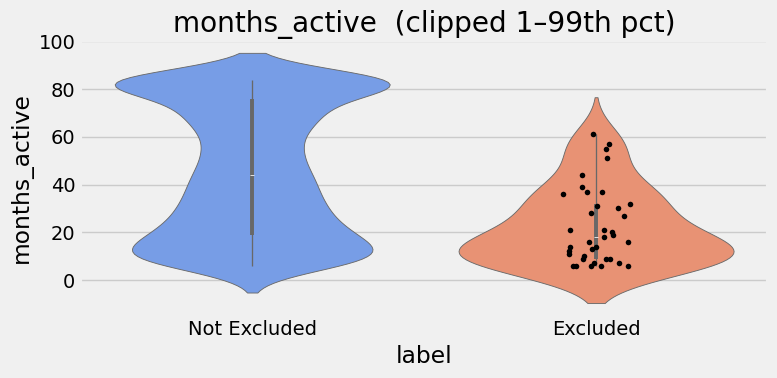

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


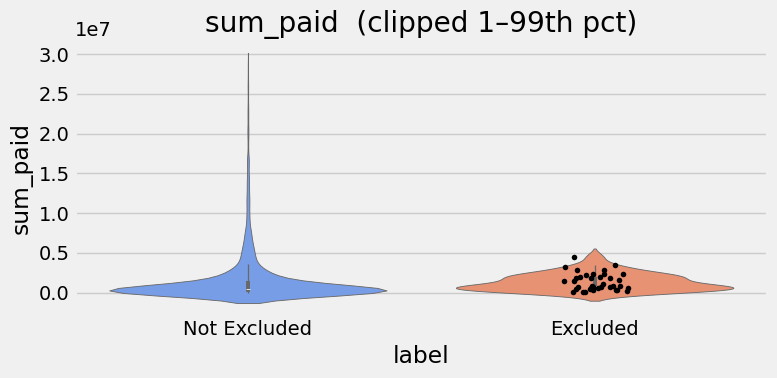

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


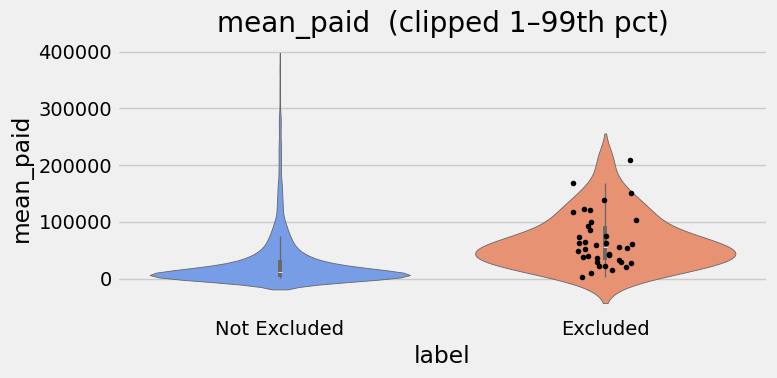

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


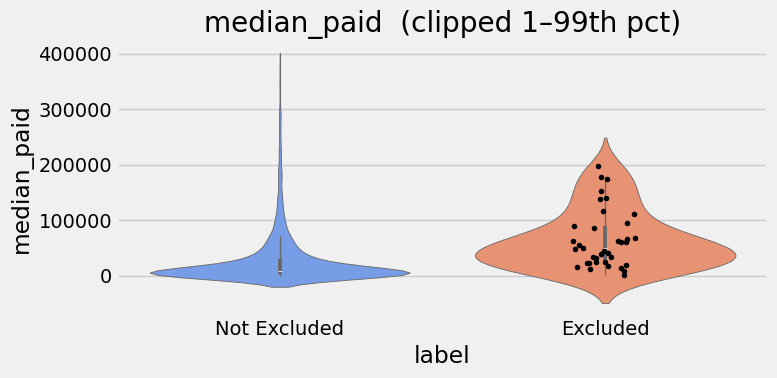

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


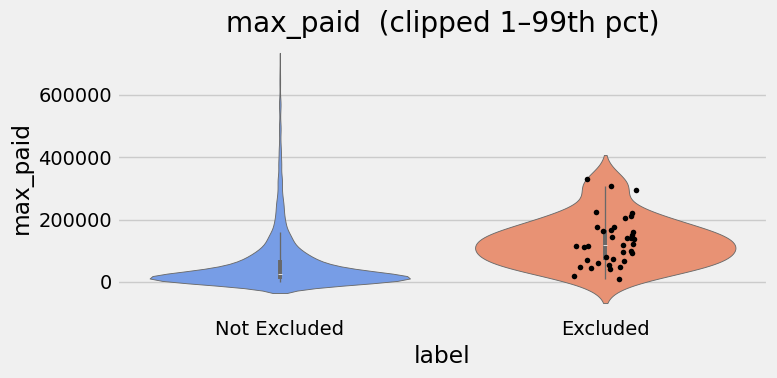

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


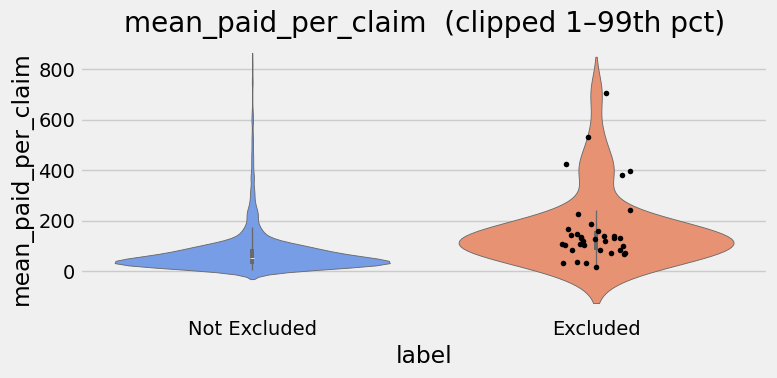

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


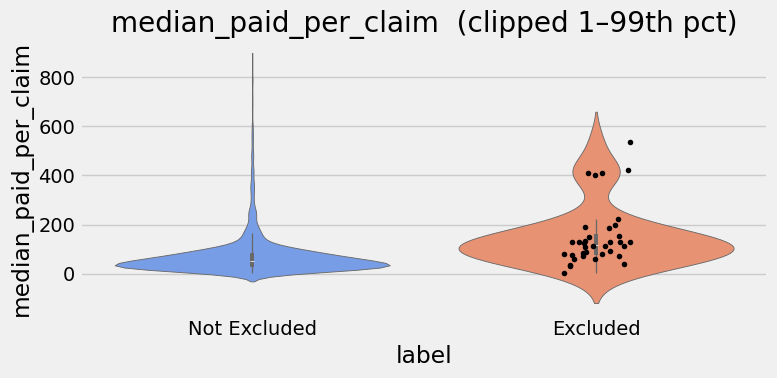

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


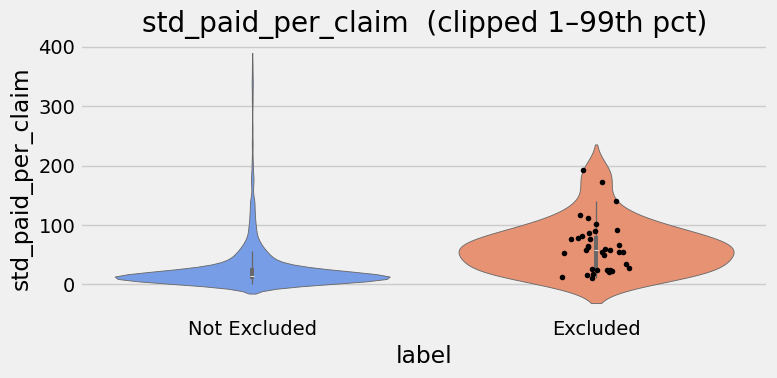

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


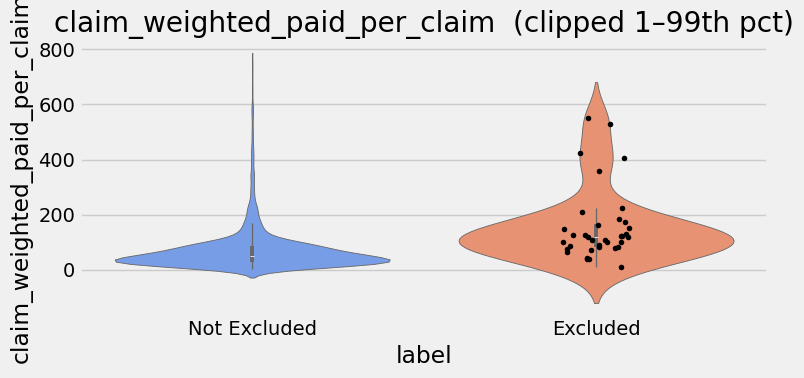

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


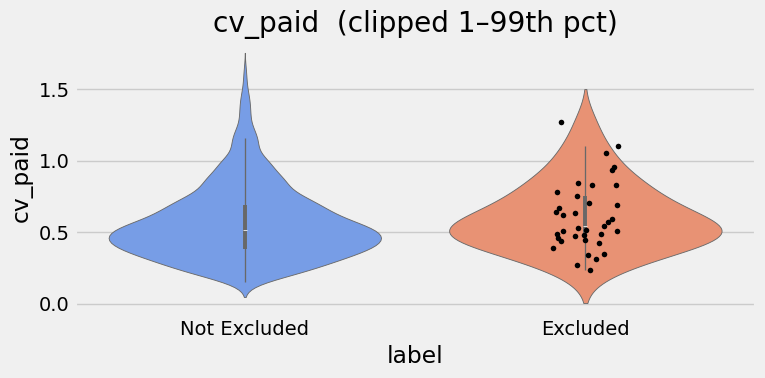

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


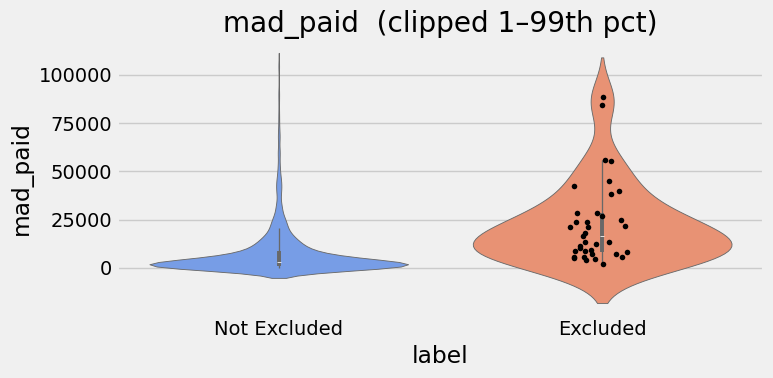

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


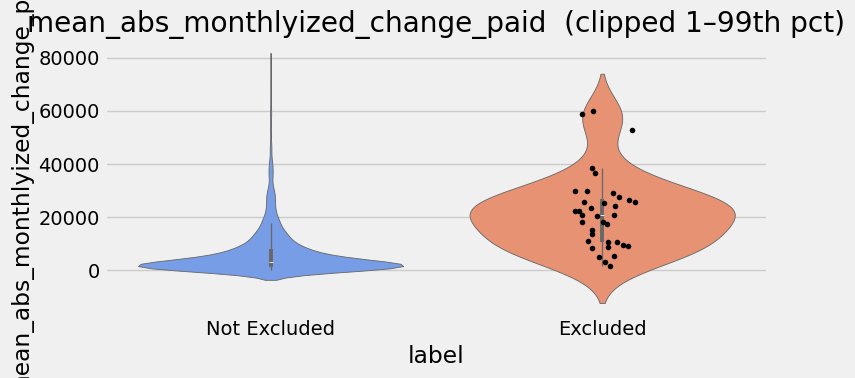

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


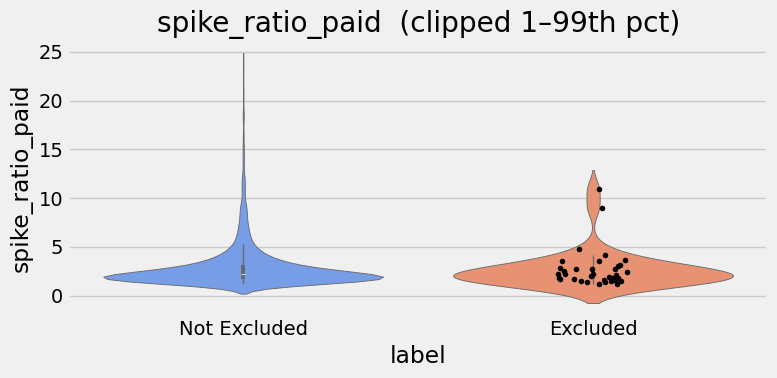

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


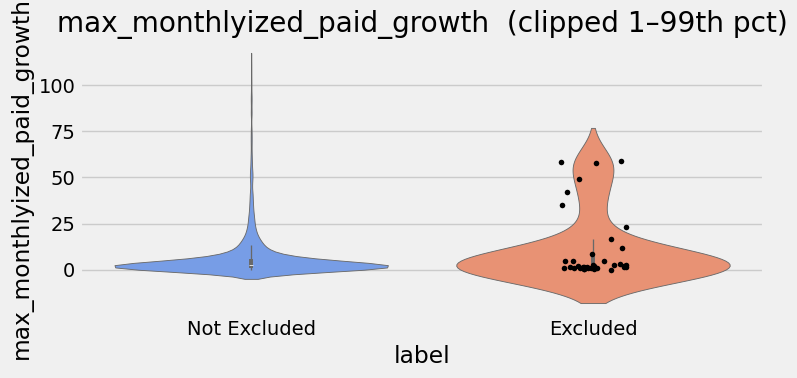

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


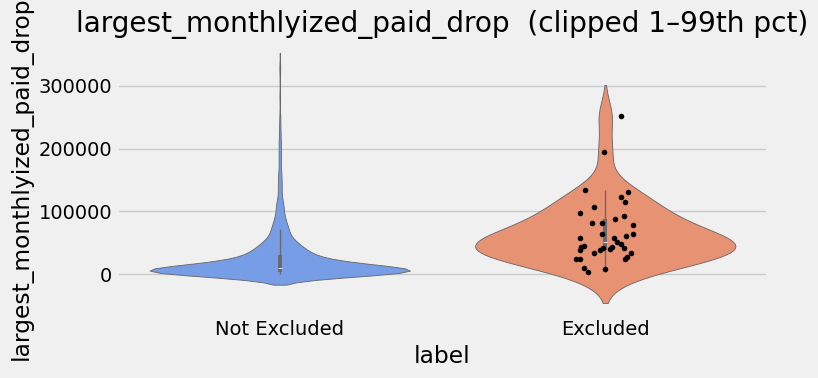

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


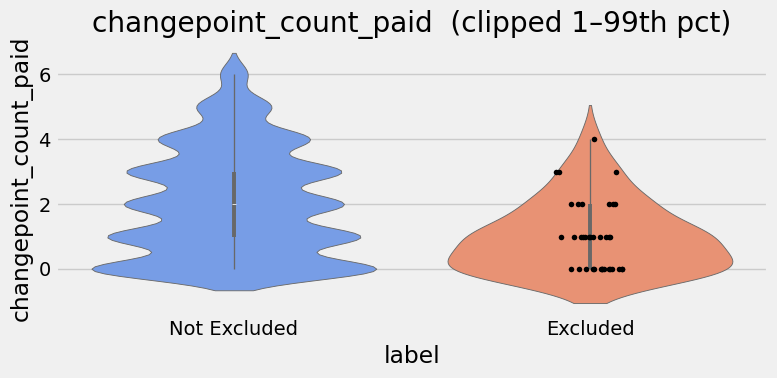

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


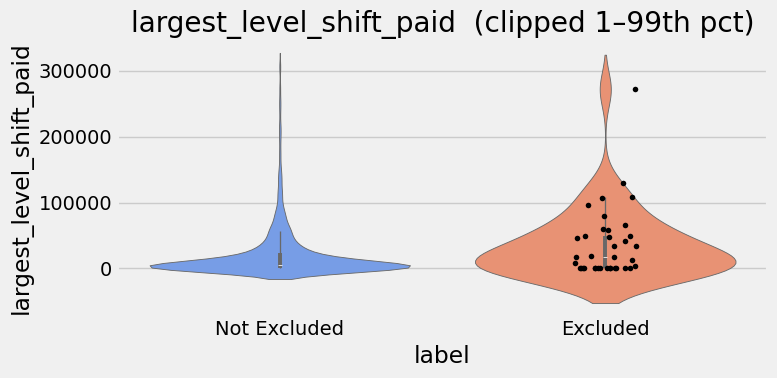

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


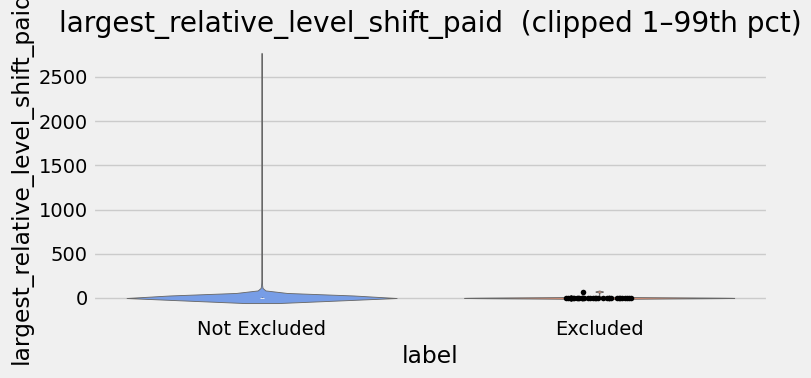

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


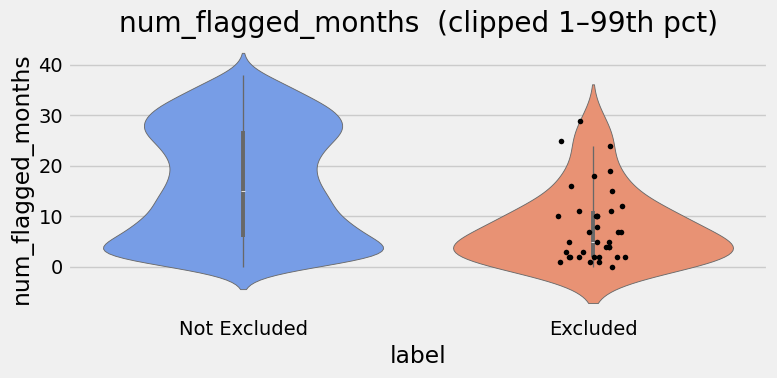

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


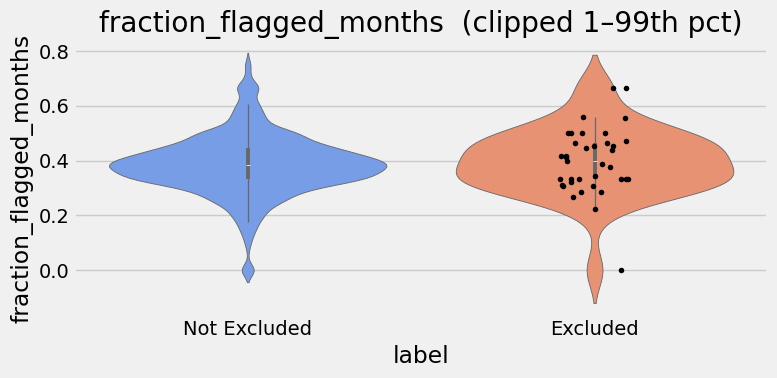

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


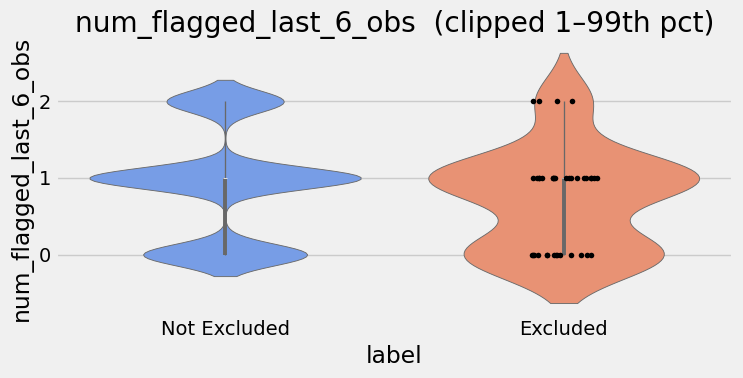

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


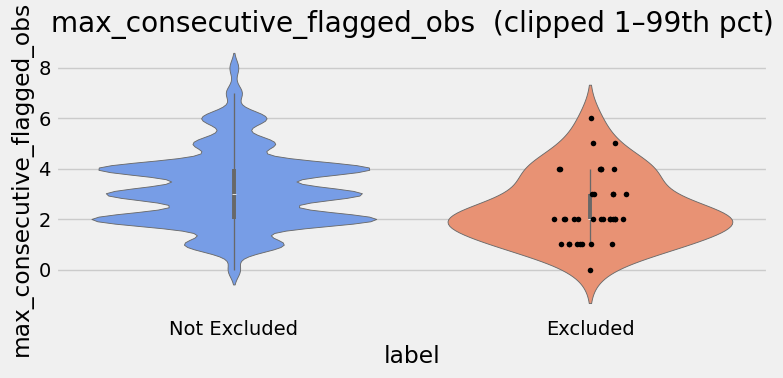

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


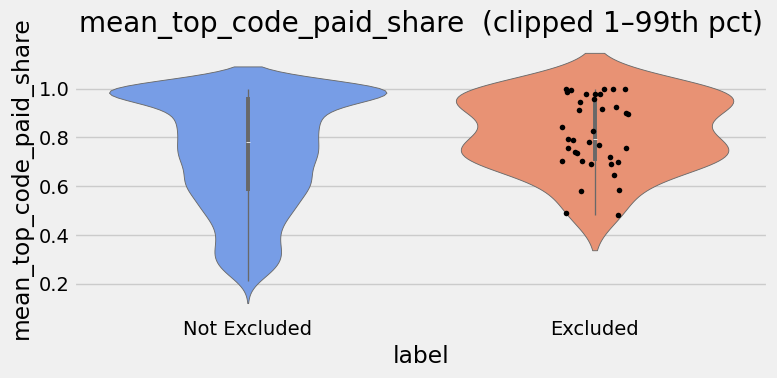

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


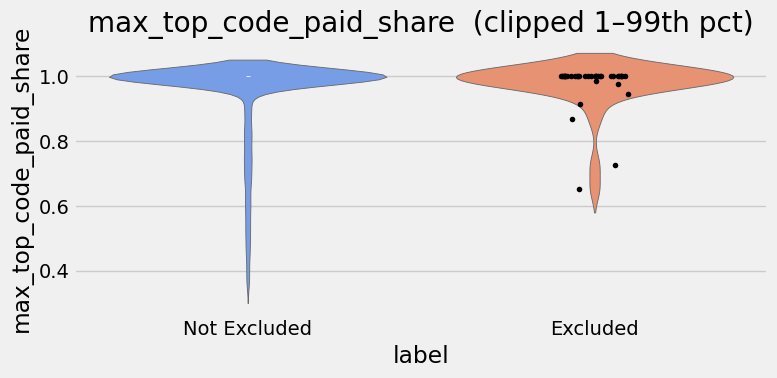

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


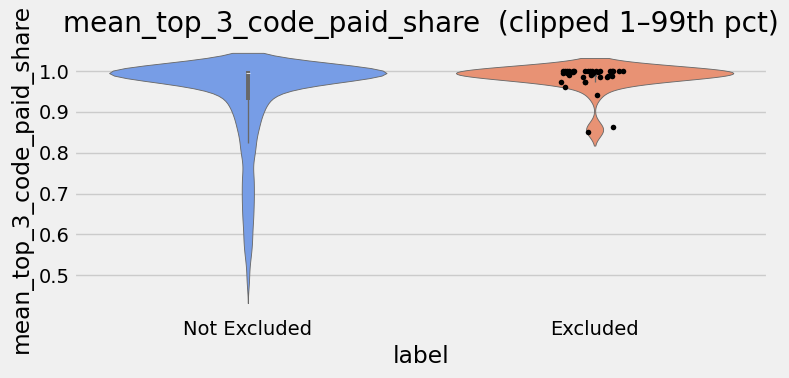

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


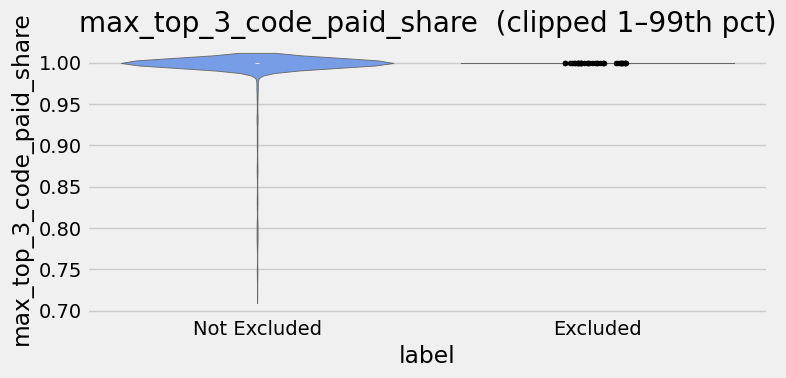

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


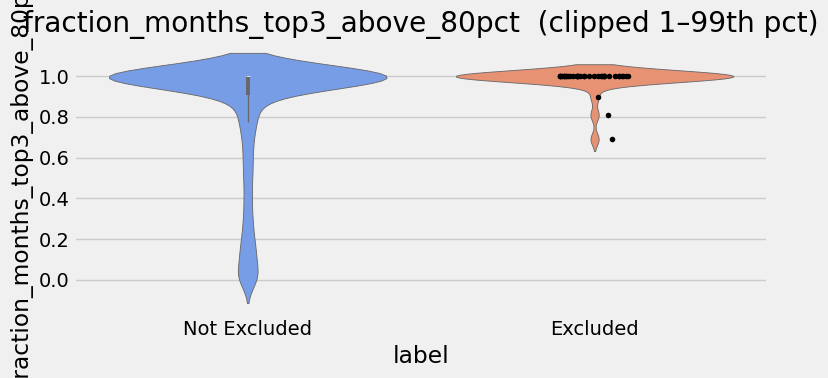

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


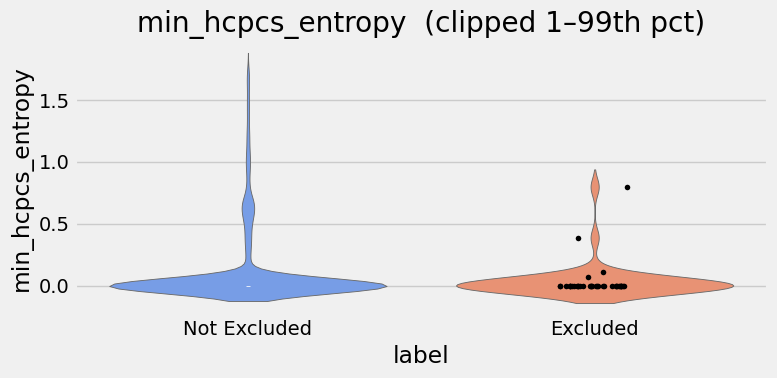

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


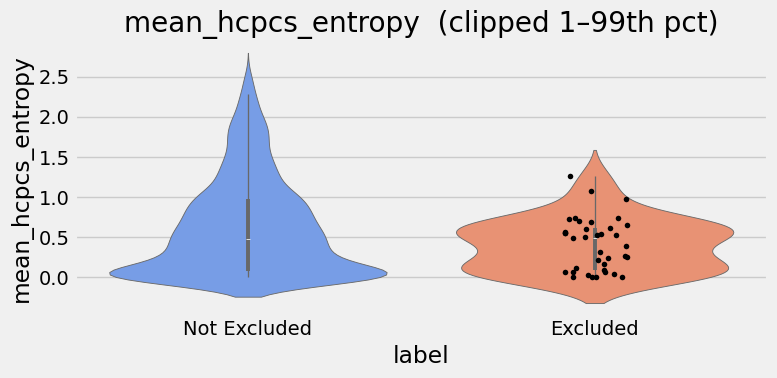

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


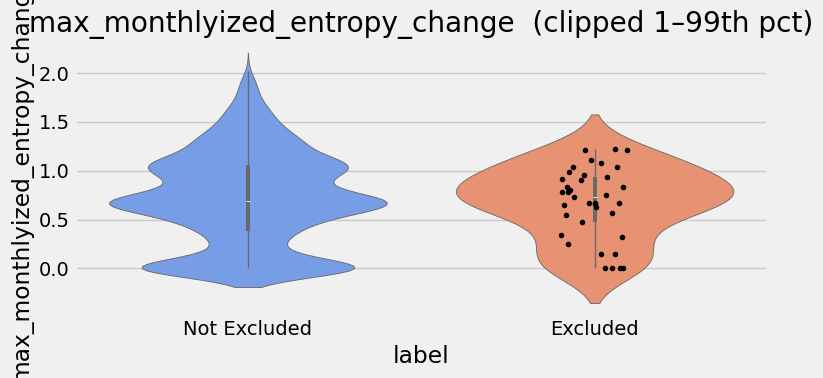

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


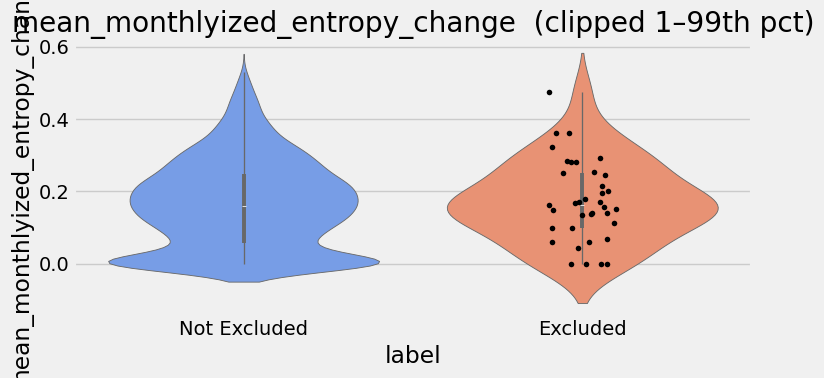

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


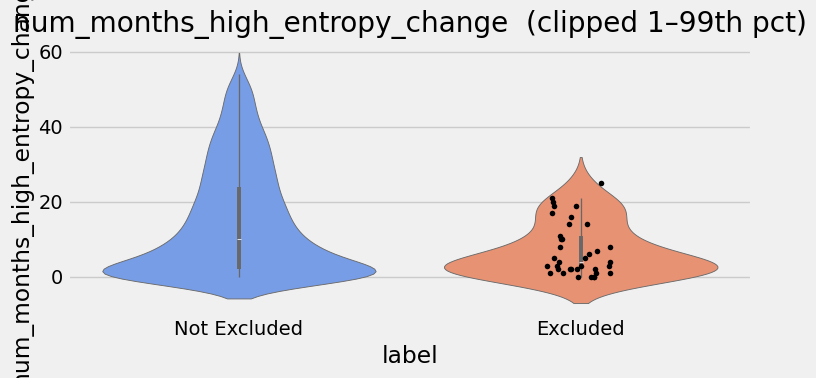

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


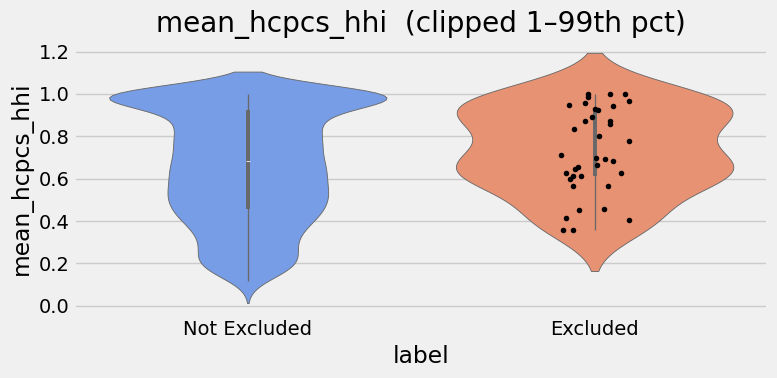

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


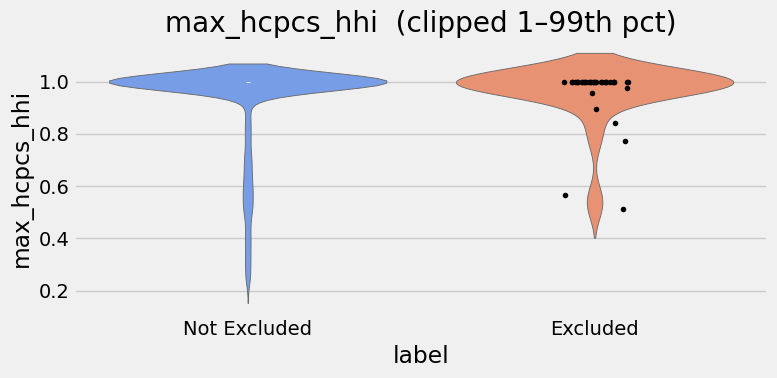

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


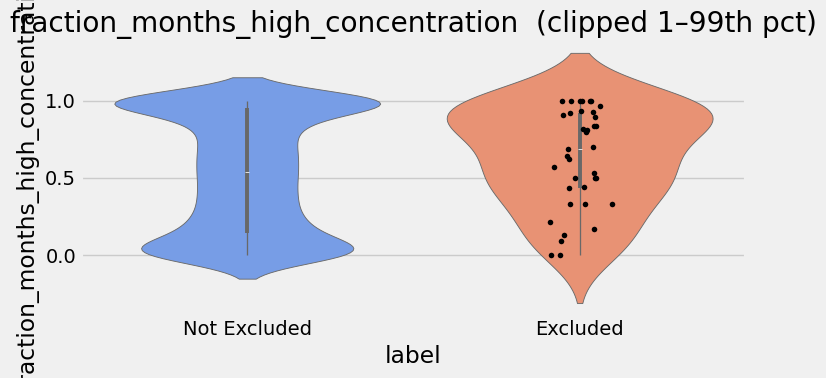

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


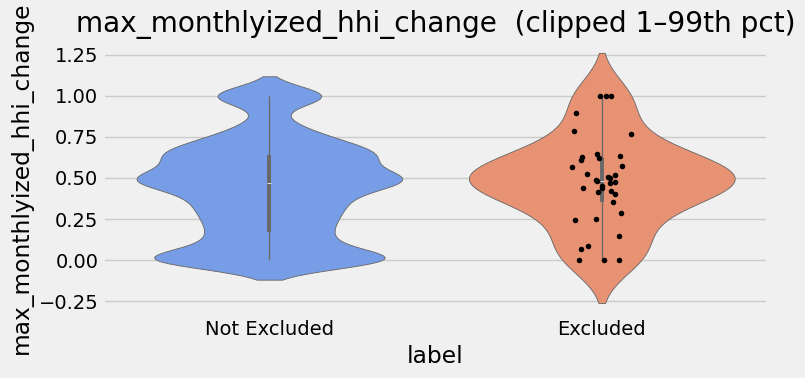

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


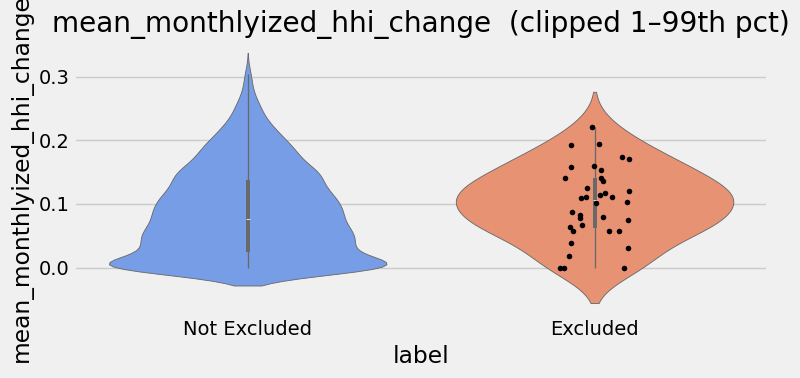

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


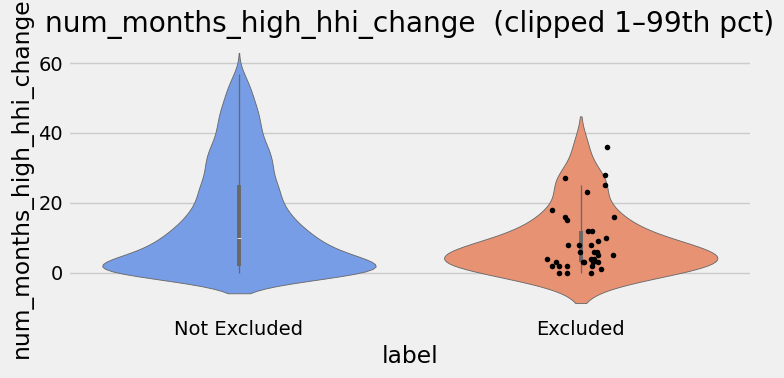

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


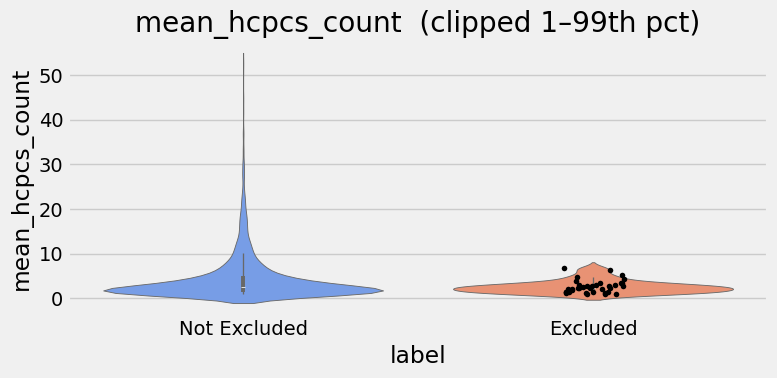

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


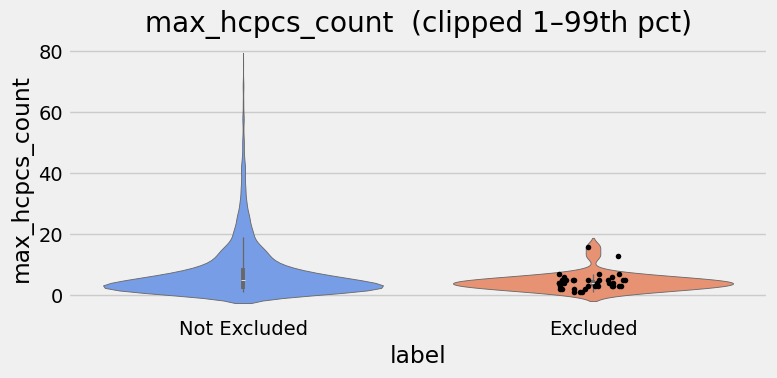

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


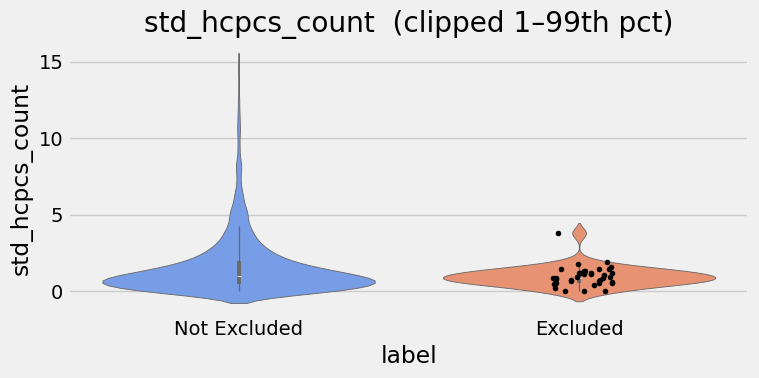

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


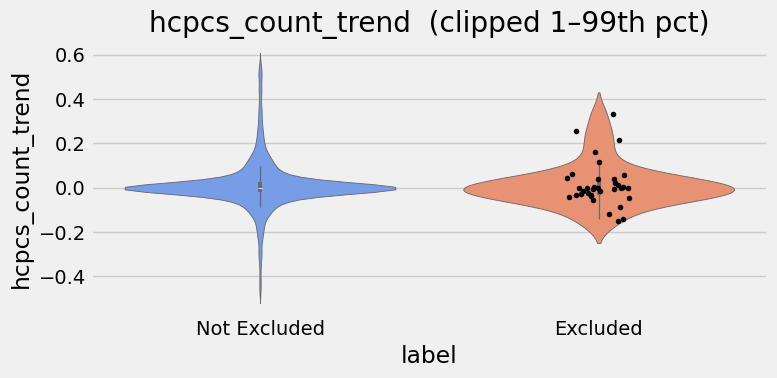

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_69487/2694374038.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


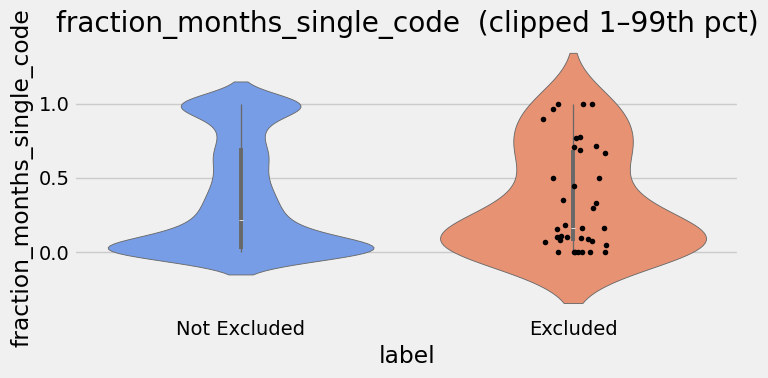

In [28]:
for feat in features:
    fig, ax = plt.subplots(figsize=(8, 4))
    
    q01 = df[feat].quantile(0.01)
    q99 = df[feat].quantile(0.99)
    plot_df = df[df[feat].between(q01, q99)]
    
    sns.violinplot(data=plot_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], inner='box')
    sns.stripplot(data=plot_df[plot_df['label']==1], x='label', y=feat, ax=ax, color='black', size=4, jitter=True)
    ax.set_title(f'{feat}  (clipped 1–99th pct)')
    ax.set_xticklabels(['Not Excluded', 'Excluded'])
    plt.tight_layout()
    plt.show()

In [39]:
from sklearn.ensemble import IsolationForest
exclude = ['label', 'billing_provider_npi', 'insufficient_history_flag', 'cohort_label']

features = [col for col in df.columns if col not in exclude]

X = df[features].dropna()
idx = X.index

iso = IsolationForest(random_state=42)
iso.fit(X)
scores = -iso.score_samples(X)  # higher = more anomalous

results = df.loc[idx, ['billing_provider_npi', 'label']].copy()
results['anomaly_score'] = scores
results = results.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

base_rate = results['label'].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}")

for k in [50, 100, 200, 500]:
    top_k = results.head(k)
    hits = top_k['label'].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float('nan')
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")


Base rate (LEIE prevalence): 0.0113
Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  100  |  LEIE hits:   1  |  Precision: 0.0100  |  Lift: 0.89x
Top  200  |  LEIE hits:   2  |  Precision: 0.0100  |  Lift: 0.89x
Top  500  |  LEIE hits:   4  |  Precision: 0.0080  |  Lift: 0.71x


/Users/adityakoushik/Desktop/hmms/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step
Base rate (LEIE prevalence): 0.0113

Top   50  |  LEIE hits:   1  |  Precision: 0.0200  |  Lift: 1.77x
Top  100  |  LEIE hits:   2  |  Precision: 0.0200  |  Lift: 1.77x
Top  200  |  LEIE hits:   6  |  Precision: 0.0300  |  Lift: 2.66x
Top  500  |  LEIE hits:   8  |  Precision: 0.0160  |  Lift: 1.42x


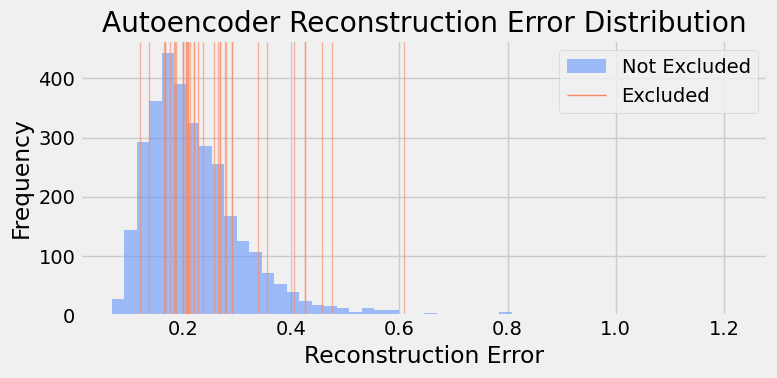

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.preprocessing import StandardScaler

exclude = ['label', 'billing_provider_npi', 'insufficient_history_flag', 'cohort_label']

features = [col for col in df.columns if col not in exclude]

X = df[features].dropna()
y = df.loc[X.index, 'label'].values
npis = df.loc[X.index, 'billing_provider_npi'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_features = X_scaled.shape[1]

# Train only on label=0 (normal) providers
X_normal = X_scaled[y == 0]

model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(n_features,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(n_features, activation='linear')
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_normal, X_normal, epochs=50, batch_size=64, validation_split=0.1, verbose=0)

reconstructions = model.predict(X_scaled)
recon_errors = np.mean(np.abs(X_scaled - reconstructions), axis=1)

results = pd.DataFrame({
    'billing_provider_npi': npis,
    'label': y,
    'recon_error': recon_errors
}).sort_values('recon_error', ascending=False).reset_index(drop=True)

base_rate = results['label'].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}\n")

for k in [50, 100, 200, 500]:
    top_k = results.head(k)
    hits = top_k['label'].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float('nan')
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")


plt.figure(figsize=(8, 4))
plt.hist(results[results['label']==0]['recon_error'], bins=50, alpha=0.6, color='#6497F9', label='Not Excluded')
for err in results[results['label']==1]['recon_error']:
    plt.axvline(x=err, color='#FB8861', alpha=0.6, linewidth=1)
plt.axvline(x=float('nan'), color='#FB8861', linewidth=1, label='Excluded')  # legend proxy
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()
